# Medication Companion — Demo Notebook

Multi-agent prescription analysis for patients in India.
Runs all **5 agents** in-process with `InMemorySessionService` and local memory — **no GCP credentials required** for Sections 2–6.

### Three ways to run this project

| Mode | What you get | Setup |
|------|--------------|-------|
| **This notebook (local/Kaggle)** | Full 5-agent ADK pipeline, sample Rx image, cross-visit memory demo | `GEMINI_API_KEY` only |
| **Local HTTP (A1)** | Same agents via auth broker JSON | `make local-auth-broker` + `scripts/test_prescription.py` |
| **Cloud E2E (A3)** | Firebase JWT, GCS upload, deployed Runtime, **real TTS audio** | See **Section 7** and `docs/smoke_test_cheatsheet.md` |

**Kaggle:** add a notebook secret `GEMINI_API_KEY` (or `GOOGLE_API_KEY`). Attach this repo as a dataset, or clone from GitHub.

**Local:** from repo root run `uv sync --group dev`, export `GEMINI_API_KEY`, then `uv run jupyter notebook notebooks/medication_companion_demo.ipynb`.

> **Disclaimer:** Educational prototype, not a medical device. Not a substitute for pharmacist or doctor advice.


## 1. Setup

**API key:** set `GEMINI_API_KEY` (or `GOOGLE_API_KEY`) to run Sections 5–6 (LLM + vision). Sections 2–4 work offline.

**Local dependency management (use `uv`, not `pip` in the terminal):**
```bash
cd medication-companion          # repo root
uv sync --group dev                # installs pyproject.toml + dev tools (jupyter)
export GEMINI_API_KEY=your-key
uv run jupyter notebook notebooks/medication_companion_demo.ipynb
```
- `uv sync` — install from lockfile (correct for local dev).
- `uv add --dev pkg` — permanently add a dev dependency to `pyproject.toml` (run in terminal only, **not** in a notebook cell).
- The next code cell may call `pip` as a **Kaggle fallback** only; it does not change `pyproject.toml`.


In [1]:
import os
import sys
from pathlib import Path

# Locate repo root whether the notebook is opened from /notebooks or repo root
cwd = Path.cwd()
if (cwd / "backend").is_dir():
    REPO_ROOT = cwd
elif (cwd.parent / "backend").is_dir():
    REPO_ROOT = cwd.parent
else:
    REPO_ROOT = cwd

BACKEND = REPO_ROOT / "backend"
sys.path.insert(0, str(BACKEND))
os.chdir(BACKEND)

os.environ.setdefault("MEMORY_BACKEND", "local")
os.environ.setdefault("ENVIRONMENT", "local")  # → Agent 5 TTS stub URL (see Section 6)
os.environ.setdefault("DEV_PATIENT_ID", "demo-patient-001")

print(f"Repo root: {REPO_ROOT}")
print(f"MEMORY_BACKEND={os.environ['MEMORY_BACKEND']}")
print(f"ENVIRONMENT={os.environ['ENVIRONMENT']} (local = stub audio_url in Agent 5)")


Repo root: /Users/alokdwivedi/dev/github/medication-companion
MEMORY_BACKEND=local
ENVIRONMENT=local (local = stub audio_url in Agent 5)


In [2]:
# Runtime dependency bootstrap — installs into THIS Jupyter kernel only.
# Does NOT modify pyproject.toml (never use `uv add` inside a notebook).
#
# LOCAL (recommended): run once in a terminal before opening the notebook:
#   uv sync --group dev
#
# KAGGLE / bare kernel: if google.adk is missing, pip-install below.
try:
    import google.adk  # noqa: F401
except ImportError:
    import sys

    print("google-adk not found — installing into the active notebook kernel...")
    print("(For local dev, prefer: uv sync --group dev  from repo root)")
    get_ipython().run_line_magic(
        "pip",
        "install -q google-adk rapidfuzz pydantic python-dotenv",
    )


## 2. In-memory session & memory services

Day 3 (Context Engineering): short-term session state + long-term cross-visit memory.

In [3]:
from google.adk.sessions import InMemorySessionService
from memory.session_service import create_session_service
from memory.memory_service import create_memory_service

session_service = create_session_service()
memory_service = create_memory_service()

assert isinstance(session_service, InMemorySessionService)
assert memory_service.is_local()
print("✓ InMemorySessionService ready")
print("✓ In-process memory store ready")

✓ InMemorySessionService ready
✓ In-process memory store ready


In [4]:
import asyncio

PATIENT_ID = os.environ["DEV_PATIENT_ID"]

async def demo_cross_visit_memory():
  # Visit 1: patient was prescribed warfarin
  await memory_service.save_visit(
      patient_id=PATIENT_ID,
      resolved_drug_names=["warfarin"],
      severity="INFO",
  )
  # Visit 2: new prescription includes aspirin (known interaction with warfarin)
  history = await memory_service.get_medications_for_patient(PATIENT_ID)
  print(f"Prior visits for {PATIENT_ID}: {len(history)}")
  for visit in history:
      print(f"  {visit['visit_timestamp'][:10]} — {visit['resolved_drugs']} ({visit['severity_summary']})")

await demo_cross_visit_memory()

Prior visits for dev-patient-001: 1
  2026-06-29 — ['warfarin'] (INFO)


## 3. Build the 5-agent pipeline

| Agent | Role | Course day |
|-------|------|------------|
| 1 Reader | OCR + Gate 1 confidence check | Day 1 |
| 2 Resolver | Brand → generic, FDC split (FunctionTools) | Day 2 |
| 3 Safety | Cross-visit interaction check (memory) | Day 3 |
| 4 Education | Plain-language explanation | Day 1 |
| 5 Localisation | Translate + TTS (in-process SequentialAgent step) | Day 2 |

Production orchestration: `backend/agent.py` — `SequentialAgent` with policy callbacks and Memory Bank persistence.

In [5]:
from google.adk.agents import SequentialAgent
from agents.agent1_reader import create_reader_agent
from agents.agent2_resolver import create_resolver_agent
from agents.agent3_safety import create_safety_agent
from agents.agent4_education import create_education_agent
from agents.agent5_localisation import create_localisation_agent

reader_agent = create_reader_agent()
resolver_agent = create_resolver_agent()
safety_agent = create_safety_agent(memory_service=memory_service)
education_agent = create_education_agent()
localisation_agent = create_localisation_agent()

root_agent = SequentialAgent(
    name="medication_companion",
    sub_agents=[
        reader_agent,
        resolver_agent,
        safety_agent,
        education_agent,
        localisation_agent,
    ],
)

agents = {
    "1_reader": reader_agent,
    "2_resolver": resolver_agent,
    "3_safety": safety_agent,
    "4_education": education_agent,
    "5_localisation": localisation_agent,
}
for name, agent in agents.items():
    print(f"✓ {name}: {agent.name}")

✓ 1_reader: prescription_reader
✓ 2_resolver: medication_resolver
✓ 3_safety: medication_safety
✓ 4_education: patient_education
✓ 5_localisation: localisation_audio


/var/folders/7w/rpdt250519x332ww6xcspbnh0000gp/T/ipykernel_38159/1622884087.py:14: DeprecationWarning: SequentialAgent is deprecated and will be removed in future versions. Please use Workflow instead.
  root_agent = SequentialAgent(


## 4. Tool demo (Agent 2) — no LLM required

Indian brand lookup from bundled CSV + FDC splitting.

In [6]:
from tools.drug_lookup import drug_lookup
from tools.combo_splitter import combo_splitter

for brand in ["Azee", "Augmentin", "Pantocid DSR"]:
    result = drug_lookup(brand)
    print(f"{brand:15} → {result}")
    if result.get("is_combo"):
        print(f"{'':15}   components: {combo_splitter(brand)}")

Azee            → {'generic': 'azithromycin', 'drug_class': 'Antibiotic/Macrolide', 'components': [], 'confidence': 1.0, 'source': 'csv', 'match_tier': 'csv'}
Augmentin       → {'generic': 'amoxicillin+clavulanate', 'drug_class': 'Antibiotic/Penicillin+BLI', 'components': [{'component': 'amoxicillin', 'dose': '500mg'}, {'component': 'clavulanate', 'dose': '125mg'}], 'confidence': 1.0, 'source': 'csv', 'match_tier': 'csv'}
Pantocid DSR    → {'generic': 'pantoprazole+domperidone', 'drug_class': 'PPI+Prokinetic', 'components': [{'component': 'pantoprazole', 'dose': '40mg'}, {'component': 'domperidone', 'dose': '10mg'}], 'confidence': 1.0, 'source': 'csv', 'match_tier': 'csv'}


## 5. Run the full pipeline on a sample prescription image (requires Gemini API key)

Uses the committed sample image `data/sample/test-prescritpion-normal.png` (Dr. Sharma Rx: Ecosprin, Nise, Warf, Flagyl).

This exercises **Agent 1 vision OCR** through the full `SequentialAgent` — a stronger demo than a text-only prompt (which Agent 1 correctly classifies as `non_prescription`).

Section 2 seeded warfarin in cross-visit memory; this Rx includes aspirin (Ecosprin) so Agent 3 can flag a **cross-visit** interaction.

For a deterministic smoke fixture with three known HIGH interactions, use `data/sample/smoke_4drug_2interactions.png` instead (see `docs/smoke_test_cheatsheet.md`).


Loading prescription image: test-prescritpion-normal.png


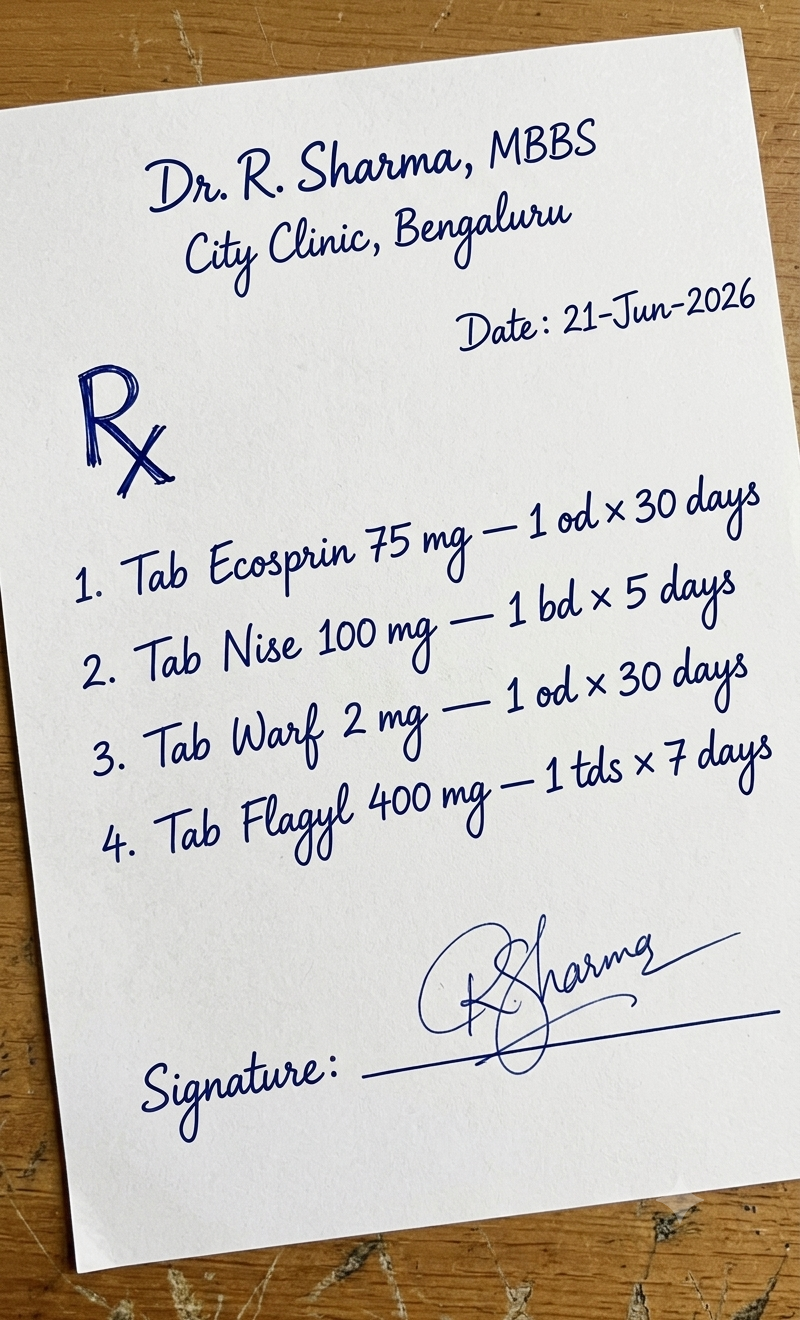

Running pipeline for patient dev-patient-001 (session 1b5c58f5-f6cb-4c04-8337-cbcc9db06dc4)...

{
  "status": "ok",
  "image_classification": "prescription",
  "extracted_drugs": [
    {
      "raw_name": "Ecosprin",
      "confidence": 1.0
    },
    {
      "raw_name": "Nise",
      "confidence": 1.0
    },
    {
      "raw_name": "Warf",
      "confidence": 1.0
    },
    {
      "raw_name": "Flagyl",
      "confidence": 1.0
    }
  ]
}


/Users/alokdwivedi/dev/github/medication-companion/.venv/lib/python3.11/site-packages/google/adk/tools/set_model_response_tool.py:116: UserWarning: [EXPERIMENTAL] feature FeatureName.JSON_SCHEMA_FOR_FUNC_DECL is enabled.
  build_function_declaration(


{"resolved_drugs": [{"raw_name": "Ecosprin", "generic_name": "aspirin", "drug_class": "Antiplatelet", "components": [], "tag": "NEW", "confidence": 1.0}, {"raw_name": "Nise", "generic_name": "nimesulide", "drug_class": "NSAID", "components": [], "tag": "NEW", "confidence": 1.0}, {"raw_name": "Warf", "generic_name": "warfarin", "drug_class": "Anticoagulant", "components": [], "tag": "NEW", "confidence": 1.0}, {"raw_name": "Flagyl", "generic_name": "metronidazole", "drug_class": "Antibiotic/Nitroimidazole", "components": [], "tag": "NEW", "confidence": 1.0}], "unresolved_count": 0}
{"interactions": [], "overall_severity": "NONE", "safe_to_proceed": true}
{
  "drug_cards": [
    {
      "display_name": "Ecosprin",
      "generic_equivalent": "aspirin",
      "tag": "NEW"
    },
    {
      "display_name": "Nise",
      "generic_equivalent": "nimesulide",
      "tag": "NEW"
    },
    {
      "display_name": "Warf",
      "generic_equivalent": "warfarin",
      "tag": "NEW"
    },
    {
  

In [7]:
from google.adk.runners import Runner
from google.genai import types
from IPython.display import Image, display
import json

api_key = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
if not api_key:
    print("Set GEMINI_API_KEY to run the full agent pipeline.")
    print("Sections 2–4 above work without an API key.")
else:
    runner = Runner(
        agent=root_agent,
        app_name="medication_companion",
        session_service=session_service,
    )

    session = await session_service.create_session(
        app_name="medication_companion",
        user_id=PATIENT_ID,
    )

    # Committed sample Rx (handwritten Indian brands). Swap filename for smoke fixture if desired.
    image_path = REPO_ROOT / "data" / "sample" / "test-prescritpion-normal.png"
    if not image_path.exists():
        raise FileNotFoundError(f"Sample prescription image not found at: {image_path}")

    print(f"Loading prescription image: {image_path.name}")
    display(Image(filename=str(image_path), width=450))

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    # Same prompt shape as docs/smoke_test_cheatsheet.md (Target language for Agent 5).
    message = types.Content(
        role="user",
        parts=[
            types.Part.from_text(
                text="Please analyse this prescription image. Target language: en-IN"
            ),
            types.Part.from_bytes(data=image_bytes, mime_type="image/png"),
        ],
    )

    print(f"Running pipeline for patient {PATIENT_ID} (session {session.id})...\n")
    latest_explanation = None
    async for event in runner.run_async(
        user_id=PATIENT_ID,
        session_id=session.id,
        new_message=message,
    ):
        if event.content and event.content.parts:
            for part in event.content.parts:
                if part.text:
                    print(part.text[:2000])
                    try:
                        data = json.loads(part.text)
                        if "summary" in data:
                            latest_explanation = data["summary"]
                    except json.JSONDecodeError:
                        pass


## 6. Agent 5 — Localisation + audio (stub in notebook)

Agent 5 (`backend/agents/agent5_localisation.py`) translates the education summary and calls the `text_to_speech` tool (`backend/tools/tts.py`).

**Why `audio_url` is `https://stub.local/audio/stub.mp3` here:**
Section 1 sets `ENVIRONMENT=local`. In that mode, `text_to_speech` returns a **stub URL immediately** — no GCP Text-to-Speech call, no GCS upload, no signed URL. This keeps the notebook runnable with **only a Gemini API key** and no GCP service account.

**Real MP3 audio** (signed `storage.googleapis.com/…` URL) is produced when:
- `ENVIRONMENT` is not `local` (production / deployed Agent Runtime), and
- GCP Text-to-Speech + GCS bucket credentials are available.

For end-to-end demo with real audio, Firebase auth, and GCS image upload, see **Section 7**.


In [ ]:
if not api_key:
    print("Set GEMINI_API_KEY to run Agent 5 localisation.")
else:
    loc_runner = Runner(
        agent=localisation_agent,
        app_name="medication_companion",
        session_service=session_service,
    )
    loc_session = await session_service.create_session(
        app_name="medication_companion",
        user_id=PATIENT_ID,
    )

    # Prefer Agent 4 output from Section 5; fall back for standalone runs.
    english_summary = globals().get("latest_explanation")
    if not english_summary:
        print("Note: No dynamic explanation from Section 5 — using fallback text.")
        english_summary = (
            "Ecosprin (aspirin) may interact with warfarin from your prior visit. "
            "This combination can increase bleeding risk. "
            "Please discuss this with your doctor or pharmacist before making any changes."
        )
    else:
        print(f"Using Agent 4 summary:\n\"{english_summary}\"\n")

    loc_message = types.Content(
        role="user",
        parts=[types.Part(text=f"Target language: hi-IN\n\n{english_summary}")],
    )

    agent5_payload = None
    async for event in loc_runner.run_async(
        user_id=PATIENT_ID,
        session_id=loc_session.id,
        new_message=loc_message,
    ):
        if event.content and event.content.parts:
            for part in event.content.parts:
                if part.text:
                    print(part.text)
                    try:
                        agent5_payload = json.loads(part.text)
                    except json.JSONDecodeError:
                        pass

    if agent5_payload:
        audio_url = agent5_payload.get("audio_url", "")
        print("\n--- Agent 5 result ---")
        print(f"language_code : {agent5_payload.get('language_code')}")
        print(f"audio_url     : {audio_url}")
        if audio_url.startswith("https://stub.local/"):
            print(
                "\nStub audio URL (ENVIRONMENT=local). "
                "Production TTS uploads an MP3 to GCS — see Section 7 for cloud E2E."
            )
        elif audio_url.startswith("https://storage.googleapis.com/"):
            print("\nReal GCS signed audio URL — open in a browser to play.")


## 7. Cloud E2E — real audio, Firebase, GCS (not runnable in this notebook)

This notebook deliberately avoids GCP credentials. The **production path** is the same stack tested in `docs/smoke_test_cheatsheet.md`:

### A3 · Cloud Agent Runtime + auth broker (sync)

Prerequisites: deployed backend (`make deploy-backend`), Firebase test user in `.env`, sample image.

```bash
export GCP_PROJECT=medication-companion-dev
export RX_IMAGE=data/sample/smoke_4drug_2interactions.png

# Firebase JWT (reads FIREBASE_TEST_EMAIL / FIREBASE_TEST_PASSWORD from .env)
export FIREBASE_ID_TOKEN="$(uv run python scripts/firebase_id_token.py --print-token-only)"

uv run python scripts/test_prescription.py "$RX_IMAGE" \
  --url https://$GCP_PROJECT.web.app \
  --token "$FIREBASE_ID_TOKEN" \
  --language hi-IN
```

**Pass criteria:** JSON `PrescriptionResult` with resolved drugs, interactions, and `audio_url` as a real `storage.googleapis.com/…` signed URL (not `stub.local`).

### Other smoke paths (same cheatsheet)

| Scenario | Command | Real TTS? |
|----------|---------|----------|
| **A1** local broker + in-process runner | `make local-auth-broker` + `test_prescription.py --url http://localhost:8080` | No (stub while `ENVIRONMENT=local`) |
| **A2b** deployed Runtime direct | `agents-cli run --url … --file "$RX_IMAGE"` | Yes |
| **A3** full cloud via Hosting | see above | Yes |
| **C** Flutter PWA | open `https://$GCP_PROJECT.web.app` | Yes |

Full deploy steps: `docs/deployment_runbook.md`.
